# Chapter 52 — Linear Models: The First Step Toward Intelligence
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 52 — Linear Models: The First Step Toward Intelligence.

The simplest question a machine can be asked from strain data is a regression question: *given these gage readings, what was the applied load?* Linear regression answers it by finding the weighted combination of input features that best predicts the output. When the underlying physics is linear — as it is for an elastic structure operating in its design range — linear regression is not a simplification; it is an **exact** model, and the coefficients it learns correspond to identifiable physical quantities.

In a multi-gage load cell or a structural-health-monitoring array, each gage responds to load in proportion to its position and sensitivity. Linear regression learns these proportionality factors from calibration data: a set of weights that maps gage readings to a load estimate. This is the same operation performed by hand in classical load-cell calibration, now automated, checked against held-out data, and generalized to many correlated inputs. When gages are strongly correlated — as they are here, since all three respond to the same load — ordinary least squares can still be fragile, and a regularized variant (*ridge regression*) is the standard remedy; we point to that as an extension at the end rather than needing it for this well-conditioned example.

**This notebook demonstrates:**
1. **Multi-gage load prediction** with ordinary least squares — a three-gage array, a train/test split, five-fold cross-validation, and a predicted-vs-true scatter with residuals (Figure 52.3).
2. **Single-feature regression** of load against one strain channel, with the closed-form slope and intercept, a 95% confidence band, and a residual diagnostic (Figure 52.2).
3. **A polynomial thermal-output curve** — a fourth-order fit in temperature that is *still a linear model*, because "linear" means linear in the coefficients, not in the inputs (Figure 52.1).

In [1]:
# !pip install numpy matplotlib scikit-learn

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Seed every source of randomness so the datasets and figures are reproducible.
RANDOM_SEED = 12

# All generated figures are written here (the exact paths the book includes).
OUT_DIR = Path("../src/media/ch52")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Load Prediction from a Three-Gage Array (Figure 52.3)

The simulation below builds a 200-sample calibration dataset: three strain gages responding to a random applied load in the range 0–10,000 N. Gage 1 has the highest sensitivity (0.85 με/N), Gage 2 is moderate (0.40 με/N), and Gage 3 the lowest (0.20 με/N), each with noise scaled to its role. The task is to recover the applied load from the three gage readings.

We standardize the features and fit ordinary least squares *inside a pipeline*, so the scaler is refit within each cross-validation fold rather than once on the whole dataset — fitting it on all the data before splitting would leak information from the held-out fold into the scaling. A 25% hold-out test set and five-fold cross-validation both report R² ≈ 0.99 with an RMSE well below 200 N — the expected result for an elastic structure whose response is genuinely linear. The scatter plot shows predicted vs. true load hugging the 45° identity line; the residual plot shows errors that are random and homoscedastic (uniform variance across the load range), with no systematic trend that would betray a model-specification error.

Having validated the model, we refit it on *all* the data for the deployed calibration curve — standard practice once the held-out check has done its job. The learned coefficients rank the gages by their contribution to the load estimate: Gage 1 receives the largest weight (highest sensitivity), Gage 3 the smallest. If the physical sensitivity ratios were known from FEA or an analytical model, they could be compared against these coefficients as a consistency check — a practice that bridges classical calibration and data-driven modeling.

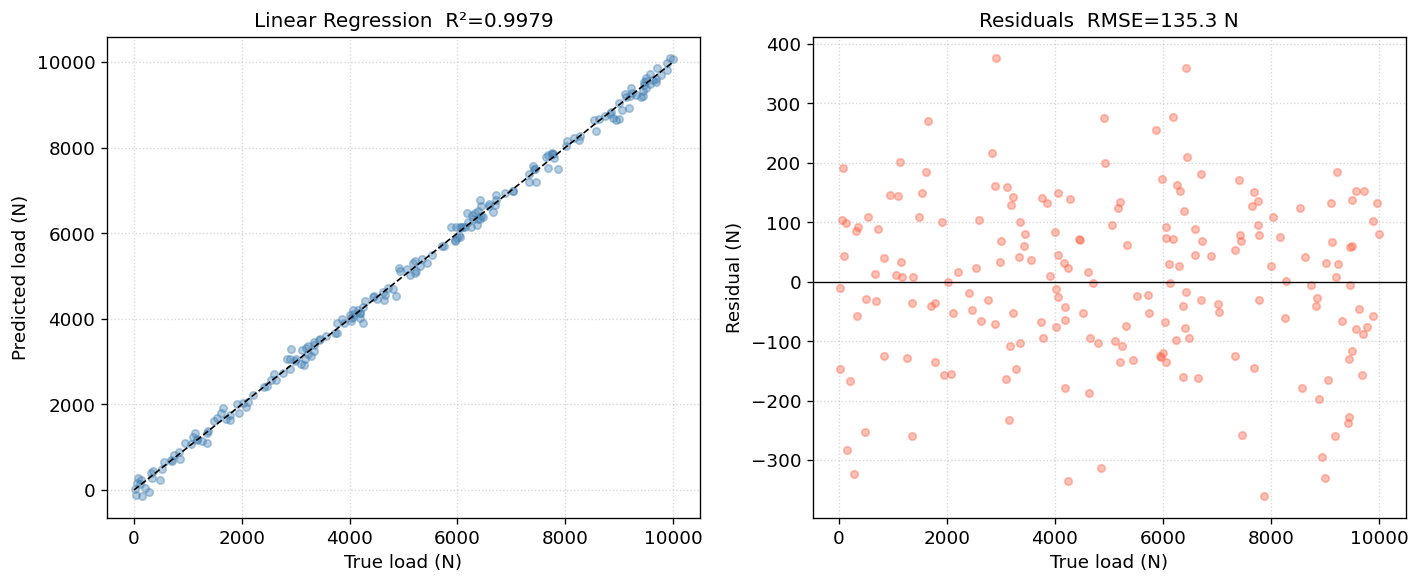

Full-fit    R² = 0.9979,  RMSE = 135.3 N
Held-out    R² = 0.9987,  RMSE = 118.5 N  (25% test set)
5-fold CV   R² = 0.9977 ± 0.0006
Scaled coefficients: ε1=1676.9  ε2=902.7  ε3=365.4


In [2]:
# Section 1: multi-gage load prediction (Figure 52.3)
N_SAMPLES = 200
LOAD_MAX_N = 10_000.0                   # applied load spans 0 .. LOAD_MAX_N (N)
GAGE_SENSITIVITY = (0.85, 0.40, 0.20)   # microstrain per newton, gage 1..3
GAGE_NOISE_UE = (150.0, 100.0, 80.0)    # gage noise std dev (microstrain), gage 1..3
N_CV_FOLDS = 5
TEST_FRACTION = 0.25


def simulate_gage_array(n_samples, load_max, sensitivities, noise_levels, seed):
    """Simulate a multi-gage load-cell calibration dataset.

    Draws ``n_samples`` random applied loads uniformly in ``[0, load_max]`` and,
    for each gage, returns a noisy strain reading of the form
    ``sensitivity * load + Gaussian noise``.

    Parameters
    ----------
    n_samples : int
        Number of calibration points to generate.
    load_max : float
        Upper bound of the applied-load range, in newtons.
    sensitivities : sequence of float
        Per-gage sensitivity, in microstrain per newton.
    noise_levels : sequence of float
        Per-gage Gaussian noise standard deviation, in microstrain.
    seed : int
        Seed for NumPy's global RNG, for reproducibility.

    Returns
    -------
    X : ndarray, shape (n_samples, n_gages)
        Strain readings (microstrain), one column per gage.
    load : ndarray, shape (n_samples,)
        The true applied load (N) for each sample.
    """
    np.random.seed(seed)
    load = np.random.uniform(0, load_max, n_samples)
    columns = [s * load + np.random.normal(0, sigma, n_samples)
               for s, sigma in zip(sensitivities, noise_levels)]
    return np.column_stack(columns), load


X, y = simulate_gage_array(N_SAMPLES, LOAD_MAX_N, GAGE_SENSITIVITY,
                           GAGE_NOISE_UE, seed=RANDOM_SEED)

# Standardize + fit OLS inside a pipeline so the scaler is refit within each
# CV fold (fitting it once on the full set would leak held-out information).
model = make_pipeline(StandardScaler(), LinearRegression())

# Honest generalization estimate: a held-out test set and k-fold CV.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
test_r2 = r2_score(y_test, model.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
cv_scores = cross_val_score(
    model, X, y, scoring='r2',
    cv=KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED))

# Refit on all data for the deployed calibration model, then plot its fit.
model.fit(X, y)
y_pred = model.predict(X)
r2_full = r2_score(y, y_pred)
residuals = y_pred - y
rmse_full = np.sqrt(np.mean(residuals ** 2))
coef = model.named_steps['linearregression'].coef_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y, y_pred, alpha=0.4, color='steelblue', s=20)
axes[0].plot([0, 10000], [0, 10000], 'k--', lw=1)
axes[0].set_xlabel('True load (N)'); axes[0].set_ylabel('Predicted load (N)')
axes[0].set_title(f'Linear Regression  R²={r2_full:.4f}')
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].scatter(y, residuals, alpha=0.4, color='tomato', s=20)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('True load (N)'); axes[1].set_ylabel('Residual (N)')
axes[1].set_title(f'Residuals  RMSE={rmse_full:.1f} N')
axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig52_nb1_load_prediction_regression.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Full-fit    R² = {r2_full:.4f},  RMSE = {rmse_full:.1f} N")
print(f"Held-out    R² = {test_r2:.4f},  RMSE = {test_rmse:.1f} N  (25% test set)")
print(f"{N_CV_FOLDS}-fold CV   R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scaled coefficients: ε1={coef[0]:.1f}  ε2={coef[1]:.1f}  ε3={coef[2]:.1f}")

---
## 2 — Single-Feature Regression with a Confidence Band (Figure 52.2)

The most transparent linear model has a single input. Here one strain channel is regressed against applied load: the closed-form ordinary-least-squares slope $w$ is the load sensitivity, the intercept $b$ is the offset, and the shaded 95% confidence band shows the uncertainty in the *mean* fitted response (widest at the ends of the strain range, tightest near the centroid). The residual panel is the key diagnostic: residuals scattered randomly about zero, with no curvature or fanning, confirm that a straight line is an adequate model for this data.

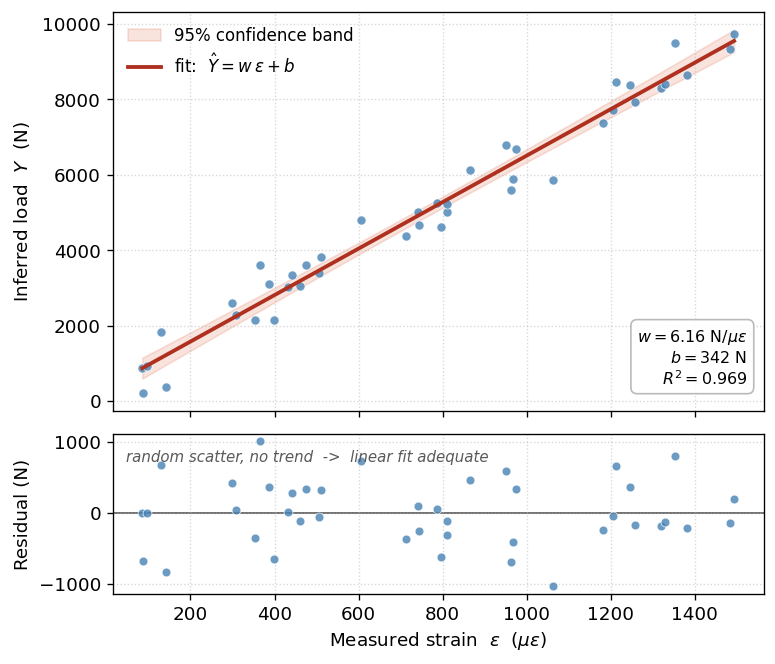

R2=0.969


In [3]:
# Section 2: single-feature strain->load OLS fit with a 95% CI band (Figure 52.2)
N_POINTS = 42
STRAIN_MIN_UE, STRAIN_MAX_UE = 80.0, 1500.0   # measured strain range (microstrain)
W_TRUE, B_TRUE = 6.2, 300.0                    # true sensitivity (N/microstrain), offset (N)
LOAD_NOISE_N = 520.0                           # scatter in the inferred load (N)
T_CRIT_975 = 2.021                             # Student-t, 0.975 quantile, dof = N_POINTS - 2


def ols_line(x, y):
    """Closed-form ordinary-least-squares fit of a straight line y = w*x + b.

    Returns the slope ``w``, intercept ``b``, per-point residuals, the residual
    standard error ``s`` (with n-2 degrees of freedom), the coefficient of
    determination ``R2``, and the mean and centered sum-of-squares of ``x``
    (``xbar`` and ``Sxx``, needed for the confidence band).
    """
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.sum((x - xbar) ** 2)
    w = np.sum((x - xbar) * (y - ybar)) / Sxx
    b = ybar - w * xbar
    resid = y - (w * x + b)
    s = np.sqrt(np.sum(resid ** 2) / (x.size - 2))
    R2 = 1.0 - np.sum(resid ** 2) / np.sum((y - ybar) ** 2)
    return w, b, resid, s, R2, xbar, Sxx


rng = np.random.default_rng(7)
eps = np.sort(rng.uniform(STRAIN_MIN_UE, STRAIN_MAX_UE, N_POINTS))    # microstrain
Yld = W_TRUE * eps + B_TRUE + rng.normal(0, LOAD_NOISE_N, N_POINTS)   # inferred load, N

w, b, resid, s, R2, xbar, Sxx = ols_line(eps, Yld)

# 95% confidence band for the mean response (widest at the ends of the range).
xg = np.linspace(eps.min(), eps.max(), 240)
yg = w * xg + b
ci = T_CRIT_975 * s * np.sqrt(1.0 / N_POINTS + (xg - xbar) ** 2 / Sxx)

BLUE, RED, BAND = 'steelblue', '#b0301f', '#d9542e'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 6.3), sharex=True,
                               gridspec_kw={'height_ratios': [2.5, 1.0], 'hspace': 0.08})
ax1.fill_between(xg, yg - ci, yg + ci, color=BAND, alpha=0.16,
                 label='95% confidence band', zorder=1)
ax1.scatter(eps, Yld, s=30, color=BLUE, alpha=0.80, edgecolor='white', linewidth=0.5, zorder=3)
ax1.plot(xg, yg, color=RED, lw=2.3, zorder=4, label=r'fit:  $\hat{Y} = w\,\varepsilon + b$')
ax1.set_ylabel(r'Inferred load  $Y$  (N)')
ax1.legend(loc='upper left', frameon=False, fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.5)
stats_txt = '\n'.join([
    rf'$w = {w:.2f}$ N/$\mu\varepsilon$',
    rf'$b = {b:.0f}$ N',
    rf'$R^2 = {R2:.3f}$',
])
ax1.text(0.975, 0.06, stats_txt,
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=9.5,
         bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.7', alpha=0.9))
ax2.axhline(0, color='0.35', lw=1.0, zorder=1)
ax2.scatter(eps, resid, s=28, color=BLUE, alpha=0.80, edgecolor='white', linewidth=0.5, zorder=3)
ax2.set_xlabel(r'Measured strain  $\varepsilon$  ($\mu\varepsilon$)')
ax2.set_ylabel('Residual (N)')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.text(0.02, 0.90, 'random scatter, no trend  ->  linear fit adequate',
         transform=ax2.transAxes, ha='left', va='top', fontsize=9, color='0.35', style='italic')
fig.align_ylabels([ax1, ax2])
fig.savefig(OUT_DIR / 'fig52_nb2_linear_regression.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('R2=%.3f' % R2)

---
## 3 --- Thermal Output Correction Curve (Figure 52.1)

A strain gage's thermal output --- the apparent strain from temperature alone --- is characterized per gage lot and fitted with a third- or fourth-order polynomial in temperature. That polynomial is a *linear model* (linear in its coefficients), fit by least squares. The coefficients below are printed on the data sheet of one production lot of Constantan (A-alloy) gages self-temperature-compensated for steel, characterized on steel over -200 to +500 degF (-129 to +260 degC); the curve is near zero at room temperature (where the gage is balanced) and grows at the extremes of the range.

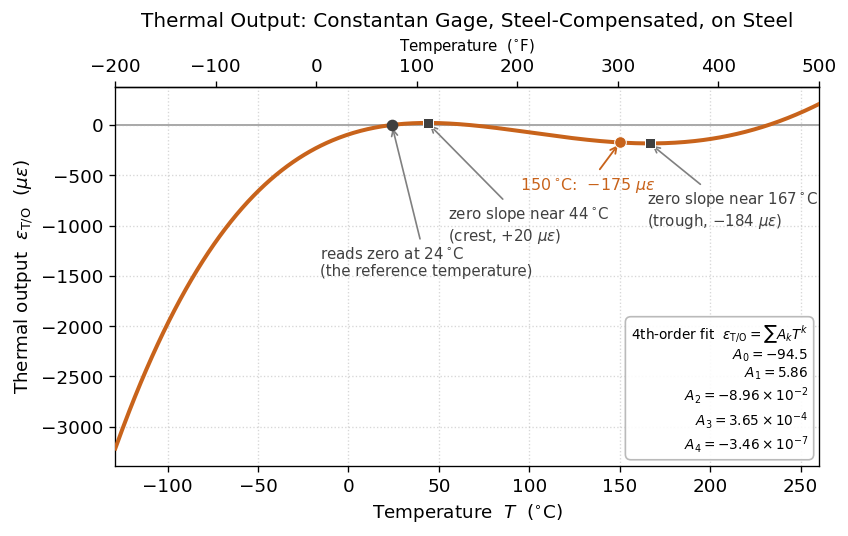

thermal output: 24C = -0.54 uE, 150C = -174.8 uE
zero slope at 43.8 C (crest, 20 uE, curvature -0.091 uE/degC^2)
zero slope at 166.6 C (trough, -184 uE, curvature 0.070 uE/degC^2)
slope at 24 C = 2.17 uE/degC


In [4]:
# Figure 52.1 --- thermal-output correction curve
# Constantan (A-alloy), self-temperature-compensated for steel, mounted on steel.
# 4th-order coefficients from one production lot's data sheet (T in degC, output in microstrain),
# valid over the data sheet's range, -200 to +500 degF (-129 to +260 degC).
A = [-9.45e1, 5.86e0, -8.96e-2, 3.65e-4, -3.46e-7]
T_LO, T_HI = (-200 - 32) * 5 / 9, (500 - 32) * 5 / 9
T = np.linspace(T_LO, T_HI, 500)
eTO = A[0] + A[1]*T + A[2]*T**2 + A[3]*T**3 + A[4]*T**4

Tw = 150.0
ew = A[0] + A[1]*Tw + A[2]*Tw**2 + A[3]*Tw**3 + A[4]*Tw**4
Tr = 24.0
er = A[0] + A[1]*Tr + A[2]*Tr**2 + A[3]*Tr**3 + A[4]*Tr**4

# The gage reads zero at the reference temperature by construction; where the curve
# has zero slope is a separate property of the STC/substrate pairing. Locate the
# stationary points (roots of the derivative) rather than assuming either coincides
# with room temperature. This curve has two inside the range: a crest and a trough.
dA = [k*A[k] for k in range(1, 5)]
_roots = np.roots(dA[::-1])
Tstat = np.sort([r.real for r in _roots if abs(r.imag) < 1e-9 and T_LO <= r.real <= T_HI])
estat = [A[0] + A[1]*t + A[2]*t**2 + A[3]*t**3 + A[4]*t**4 for t in Tstat]
curv = [2*A[2] + 6*A[3]*t + 12*A[4]*t**2 for t in Tstat]

COPPER = '#c8631b'
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.axhline(0, color='0.6', lw=1.0, zorder=1)
ax.plot(T, eTO, color=COPPER, lw=2.4, zorder=3)
ax.plot(Tr, er, 'o', color='0.25', ms=6, zorder=4)
ax.annotate(r'reads zero at $24\,^{\circ}$C' + '\n(the reference temperature)',
            xy=(Tr, er), xytext=(Tr - 40, -1500),
            fontsize=9, color='0.25', ha='left',
            arrowprops=dict(arrowstyle='->', color='0.5', lw=1.0))
# Both stationary points get the same square marker and a direct label.
_stat_text = [(r'zero slope near $%d\,^{\circ}$C' + '\n' + r'(crest, $%+d\ \mu\varepsilon$)', (55, -1150)),
              (r'zero slope near $%d\,^{\circ}$C' + '\n' + r'(trough, $%+d\ \mu\varepsilon$)', (165, -1000))]
for (t, e), (fmt, xyt) in zip(zip(Tstat, estat), _stat_text):
    ax.plot(t, e, 's', color='0.25', ms=6, mec='white', mew=0.6, zorder=4)
    ax.annotate(fmt % (round(t), round(e)), xy=(t, e), xytext=xyt,
                fontsize=9, color='0.25', ha='left',
                arrowprops=dict(arrowstyle='->', color='0.5', lw=1.0))
ax.plot(Tw, ew, 'o', color=COPPER, ms=7, mec='white', mew=0.6, zorder=5)
ax.annotate(r'$150\,^{\circ}$C:  $%d\ \mu\varepsilon$' % round(ew),
            xy=(Tw, ew), xytext=(95, -640),
            fontsize=9.5, color=COPPER, ha='left',
            arrowprops=dict(arrowstyle='->', color=COPPER, lw=1.1))
ax.set_xlabel(r'Temperature  $T$  ($^{\circ}$C)')
ax.set_ylabel(r'Thermal output  $\varepsilon_{\mathrm{T/O}}$  ($\mu\varepsilon$)')
ax.set_title('Thermal Output: Constantan Gage, Steel-Compensated, on Steel')
ax.set_xlim(T_LO, T_HI)
sec = ax.secondary_xaxis('top', functions=(lambda c: c * 9 / 5 + 32, lambda f: (f - 32) * 5 / 9))
sec.set_xlabel(r'Temperature  ($^{\circ}$F)', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
txt = ('4th-order fit  ' + r'$\varepsilon_{\mathrm{T/O}}=\sum A_k T^{k}$' + '\n'
       r'$A_0=-94.5$' + '\n' + r'$A_1=5.86$' + '\n' + r'$A_2=-8.96\times10^{-2}$' + '\n'
       + r'$A_3=3.65\times10^{-4}$' + '\n' + r'$A_4=-3.46\times10^{-7}$')
ax.text(0.985, 0.03, txt, transform=ax.transAxes, ha='right', va='bottom', fontsize=8.2,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.7', alpha=0.9))
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig52_nb3_thermal_output_curve.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('thermal output: 24C = %.2f uE, 150C = %.1f uE' % (er, ew))
for t, e, k in zip(Tstat, estat, curv):
    print('zero slope at %.1f C (%s, %.0f uE, curvature %.3f uE/degC^2)'
          % (t, 'crest' if k < 0 else 'trough', e, k))
print('slope at 24 C = %.2f uE/degC' % sum(dA[k-1]*Tr**(k-1) for k in range(1, 5)))


---
## Where to take this next

- **Regularize the correlated gages.** Swap `LinearRegression` for `Ridge` (or `RidgeCV`, which picks the penalty by cross-validation) inside Section 1's pipeline. With three gages that all track the same load, the OLS coefficients can swing to large, equal-and-opposite values; watch ridge shrink them toward a stable, physically sensible set with no loss of test R².
- **Turn estimation into a decision.** Threshold the applied load (an over-limit flag, say) and fit **logistic regression** — Eq. (52.4) in the chapter — on the same three gage features. Plot the predicted probability against load and read off the decision boundary; this is the bridge from regression to the damage-detection classifiers of later chapters.
- **Break the linearity on purpose.** Add a mild nonlinearity or drift to the synthetic gage response (a quadratic term, or a temperature-dependent sensitivity) and refit the linear model. The residual plot will stop looking flat — and that *structured* residual is exactly the cue, discussed in the chapter, to move on to the nonlinear methods of Chapter 53.